In [1]:
import os
from langchain_openai import ChatOpenAI   # openai接口
from langchain_ollama import ChatOllama   # ollama接口

In [2]:
# openai接口
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="qwen3.5-plus",             # 模型名称
    openai_api_key="sk-bvOWJIfQ8Y8IrZhzzpQZ80zSKHjWIHCkPXEgQ0H4Li5UCpUC",         # API Key
    openai_api_base="http://ai.wenmodel.com/v1", # API 地址
    temperature=0.7,
    max_tokens=1024
)

response = llm.invoke("你是谁")
print(response.content)

你好！我是 **Qwen3.5**，阿里巴巴最新推出的通义千问大语言模型。我能够协助你完成各种任务，比如：

- 📝 **写故事、写公文、写邮件、写剧本**  
- 🔍 **逻辑推理、编程、表达观点**  
- 🌐 **多语言交流（支持 100+ 语言）**  
- 📊 **分析图表、解读公式**  
- 💻 **生成代码、调试程序**  

我的知识截止至 **2026 年**，拥有 **256K 上下文窗口**，能处理长文档或复杂任务。有什么可以帮您的吗？✨


In [ ]:
# ollama接口
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3.5:0.8b",   # 必须使用支持tool-calling功能模型
    temperature=0.7,
    base_url="http://127.0.0.1:11435"
)

response = llm.invoke("你是谁")
print(response.content)

# 1.LangChain 中间件（Middleware）

在 Agent 执行的各个环节插入自定义逻辑，实现重试、降级、缓存、内容过滤、日志记录等功能——而不需要修改 Agent 本身的代码。
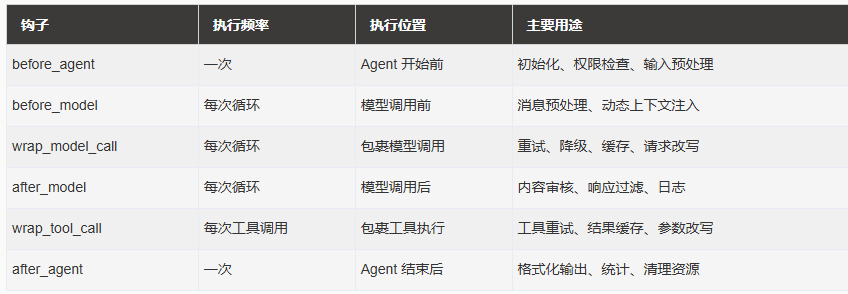

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import (
    before_agent, after_agent,
    before_model, after_model,
)

# 定义钩子

# agent开始前
@before_agent
def start_log(state, runtime):
    runtime.stream_writer({"type": "lifecycle", "phase": "start"})
    print('[start_log]执行')
    return None

# 模型每次调用前
@before_model
def pre_model(state, runtime):
    """每次模型调用前"""
    msg_count = len(state.get("messages", []))
    print(f"[before_model] 当前消息数: {msg_count}")

# 模型每次调用后
@after_model
def post_model(state, runtime):
    """每次模型调用后"""
    last = state["messages"][-1] if state.get("messages") else None
    if hasattr(last, 'tool_calls') and last.tool_calls:
        tools = [tc['name'] for tc in last.tool_calls]
        print(f"  <- [after_model] 请求工具: {tools}")
    else:
        content = str(last.content)[:50] if last and hasattr(last, 'content') else ""
        print(f"  <- [after_model] 直接回复: {content}...")
    return None

# agent结束后
@after_agent
def end_log(state, runtime):
    """Agent 结束后"""
    messages = state.get("messages", [])
    total_tokens = 0
    for msg in messages:
        if msg.type == "ai" and msg.usage_metadata:
            total_tokens += msg.usage_metadata.get(
                "total_tokens", 0
            )
    print(f"<<< [after_agent] Agent结束，共 {len(messages)} 条消息 <<<")
    print(f"Token消耗: {total_tokens}")    
    return None


In [16]:
# 创建agent
agent = create_agent(
    model=llm,
    middleware=[start_log, pre_model, end_log],
    system_prompt="你是助手。",
)


In [19]:
from langchain.messages import HumanMessage

# 构建用户输入
msg = {
    "messages": [HumanMessage(content="你是谁？")]
}

result = agent.invoke(msg)

print(result['messages'][-1].content)

[start_log]执行
[before_model] 当前消息数: 1
<<< [after_agent] Agent结束，共 2 条消息 <<<
Token消耗: 604
你好！我是一个人工智能助手。我可以帮你回答问题、提供信息、协助写作、翻译文字等等。有什么我可以帮你的吗？
